# 17. The `GounarisSakurai` lineshape

**Objectives:** evaluate the standalone `GounarisSakurai` rho -> pi pi amplitude,
confirm it is defined only for spin-1 resonances, embed it in a one-resonance
`DecayModel`, and recover the rho mass from a toy fit.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. `GounarisSakurai` is the Laura++ Gounaris-Sakurai
lineshape for `rho -> pi pi`; it must be used with `spin=1`.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, GounarisSakurai, NonResonant, Parameter,
    RealImag, Resonance, ResonanceContext, FitSession, generate_toy,
)

## 1. Spin-1 only

`GounarisSakurai.__call__` raises `ValueError` unless `context.spin == 1` -- it is
"defined for spin-1 rho-like states" per its docstring.

In [2]:
mpi = 0.13957
context_spin1 = ResonanceContext(
    parent_mass=1.869, daughter_masses=(mpi, mpi), bachelor_mass=mpi,
    spin=1, pole_mass=0.77526, pole_width=0.1491,
)
context_spin0 = ResonanceContext(**{**context_spin1.__dict__, "spin": 0})
try:
    GounarisSakurai()(jnp.asarray(0.77), context_spin0)
    raised = False
except ValueError as error:
    raised = True
    print("Raised as documented:", error)
assert raised, "GounarisSakurai must reject spin != 1"


Raised as documented: GounarisSakurai is defined for spin-1 rho-like states


## 2. Standalone amplitude

Sweeping the mass across the rho pole with the spin-1 context shows the
characteristic P-wave resonant shape.

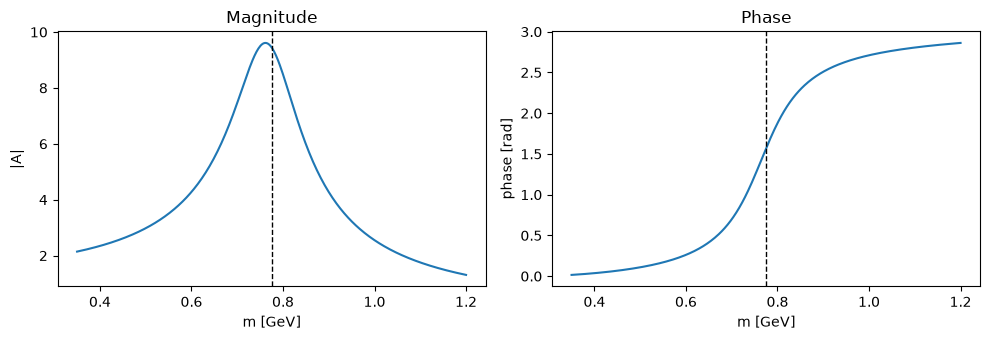

In [3]:
mass_scan = jnp.linspace(0.35, 1.2, 400)
amplitude = GounarisSakurai()(mass_scan, context_spin1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(mass_scan, jnp.abs(amplitude))
axes[0].axvline(0.77526, color="black", linestyle="--", linewidth=1)
axes[0].set(xlabel="m [GeV]", ylabel="|A|", title="Magnitude")
axes[1].plot(mass_scan, jnp.angle(amplitude))
axes[1].axvline(0.77526, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]", title="Phase")
fig.tight_layout()
plt.show()

## 3. A one-resonance Dalitz model

`GounarisSakurai` is the default choice for a rho resonance; the `Resonance` must
also declare `spin=1` so its angular factor and barrier match.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
mass = Parameter.dynamics("rho.mass", 0.77526, owner="rho",
                           bounds=(0.72, 0.83), step=0.001)
model = DecayModel(
    channel,
    components=[
        Resonance("rho", (0, 1), RealImag(1.0, 0.0), lineshape=GounarisSakurai(),
                  mass=mass, width=0.1491, spin=1),
        NonResonant(RealImag(0.30, -0.15), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=60,
)
truth = {"rho.mass": 0.77526}
print("Parameters:", [p.name for p in model.parameters])

Parameters: ['rho.mass']


## 4. Generate a toy and fit the rho mass

In [5]:
data = generate_toy(
    model, 1500, parameters=truth, seed=17,
    method="inverse-transform", inverse_resolution=256, include_momenta=False,
)
print(f"Generated {data.size} events")

session = FitSession(model, data)
result = session.fit({"rho.mass": 0.79}, simplex=True, ncall=5000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before trusting this result."


Generated 1500 events


valid=True  NLL=1511.742743
parameter                           value            error
rho.mass                         0.776804       0.00293044


Fit fractions (physical)
component                    fraction [%]
rho                                89.888
NR                                 10.112
sum                               100.000


## 5. Sanity check

In [6]:
fitted_mass = float(result.values["rho.mass"])
error = float(result.errors["rho.mass"])
print(f"truth={truth['rho.mass']:.4f}, fit={fitted_mass:.4f}, error={error:.4f}")
np.testing.assert_allclose(fitted_mass, truth["rho.mass"], atol=8 * error)
print("Rho mass recovered within 8 sigma of its Minuit error.")

truth=0.7753, fit=0.7768, error=0.0029
Rho mass recovered within 8 sigma of its Minuit error.


## Continue learning

`GounarisSakurai` is also the building block of the coherent
[rho-omega mixing lineshape](tutorial_18_rho_omega_mixing.ipynb). See
[lineshapes](../../docs/lineshapes.md).

Return to [the course guide](TUTORIALS.md).